In [1]:
import pickle
from main import Result
from src import SBsim
import pandas as pd
import matplotlib.pyplot as plt
import numpy as np
import plotly.express as px
from src import SBsim_OG
import os

In [2]:
import networkx as nx
import matplotlib.pyplot as plt

def plot_trees(ptrees):
    fig, axes = plt.subplots(1, len(ptrees), figsize=(30, 6))
    if len(ptrees) == 1:
        axes = [axes]
    
    for ax, ptree in zip(axes, ptrees):
        G = nx.DiGraph()
        pos = {}
        labels = {}
        edge_labels = {}
        
        def add_nodes_edges(node, parent=None, pos_x=0, pos_y=0, depth=1, is_left=None):
            node_id = id(node)
            pos[node_id] = (pos_x, -pos_y)
            labels[node_id] = str(node)
            G.add_node(node_id)
            
            if parent is not None:
                G.add_edge(id(parent), node_id)
                edge_labels[(id(parent), node_id)] = "True" if is_left else "False"
            
            if hasattr(node, 'l') and node.l:
                add_nodes_edges(node.l, node, pos_x - 1 / depth, pos_y + 1, depth + 1, is_left=True)
            if hasattr(node, 'r') and node.r:
                add_nodes_edges(node.r, node, pos_x + 1 / depth, pos_y + 1, depth + 1, is_left=False)
        
        add_nodes_edges(ptree.root, is_left=None)
        axes[0].set_title('Deploy Centralized')
        axes[1].set_title('Deploy Decentralized')
        axes[2].set_title('Curtailment')
        axes[3].set_title('Decommision Centralized')
        axes[4].set_title('Decommision Decentralized')
        axes[5].set_title('Decommision Curtailment')
        
        nx.draw(G, pos, with_labels=True, labels=labels, node_size=2000, node_color='lightblue', font_size=6, edge_color='gray', ax=ax)
        nx.draw_networkx_edge_labels(G, pos, edge_labels=edge_labels, font_size=10, ax=ax)
    
    plt.show()

In [3]:
# set optimization parameters
class OptimizationParameters(object):
    def __init__(self):
        self.cores    = 36 # this value is used only in the full scale optimization
        self.nseeds   = 1
        self.nobjs    = 1
        self.drought_type = [87, 0.83, 2] # set drought type here [Persistence (months), Intensity (unitless), Frequency (droughts/100 years)]

#initialize action table
action = [] #Action Name
capacity = [] #Capacity (Acre-Feet/Month)
om = [] #Operation and Maintenance Costs (Million Dollars/ Acre-Feet/ Year)
cx = [] #CAPEX (Million Dollars)
lifetime = [] #Years
t_depl = [] #Time to Deployment (Month)
action_type = [] # types 1: Deploy Centralized Infrastructure, 2: Commision Decentralized Infrastructure, 3: Decommission Centralized Infrastructure, 4: Decommission Centralized Infrastructure, 5: Conservation

#Read the action table
df_actions_table = pd.read_csv("data/actions_table.csv")
action = df_actions_table['action'].values
capacity = df_actions_table['capacity (af/month)'].values
om = df_actions_table['OPEX ($10^6/af/year)'].values
cx = df_actions_table['CAPEX($10^6)'].values
t_depl = df_actions_table['time to deployment (month)'].values
lifetime = df_actions_table['lifetime (year)'].values
action_type = [int(val) for val in df_actions_table['action_type'].values]

action_name = [[], [], [], [], []]
i = 0
for act in action:
        action_name[action_type[i]].extend( [act] )
        i += 1

opt_par = OptimizationParameters()
model_sim = SBsim(opt_par, action_name, capacity, om, cx, t_depl, lifetime) 
model_sim_OG = SBsim_OG(opt_par, action_name, capacity, om, cx, t_depl, lifetime)
#log = model_sim.simulate(obj.best_solution, 49)

Reading in one output and plotting it

In [ ]:
open_file = open("/home/gkittles/SB_DRIPP_Results/3_02_25_New_Curtailment/test_results87_0.83_15998.dat", "rb")
obj = pickle.load(open_file)

In [ ]:
plot_trees(obj.best_solution)

In [ ]:
log = model_sim.simulate(obj.best_solution, 2)

In [ ]:
indicators = np.transpose(np.array(log.indicators))

In [ ]:
plt.figure(figsize=(30,10))

plt.subplot(2,3,1);
plt.plot(indicators[0], label = 'storage');
plt.legend();

plt.subplot(2,3,2);
plt.plot(indicators[1], label='SRI1y');
plt.plot(indicators[2], label='SRI3y');
plt.legend();

plt.subplot(2,3,3);
plt.plot(indicators[3], label='Allocation1y')
plt.plot(indicators[4], label='Allocation3y')
plt.plot(indicators[5], label='Allocation5y')
plt.legend();

plt.subplot(2,3,4);
plt.plot(indicators[6], label='Delta1y');
plt.plot(indicators[7], label='Delta3y');
plt.plot(indicators[8], label='Delta5y');
plt.legend();

plt.subplot(2,3,5);
plt.plot(indicators[9], label = 'Installed');
plt.plot(indicators[10], label = 'Under Construction')
plt.legend();

plt.subplot(2,3,6);
plt.plot(indicators[11], label = 'Curtailment');
plt.legend();

In [ ]:
plt.plot(log.locations[0], label = "Desalination");
plt.plot(log.locations[1], label = "WWTP");
plt.plot(log.locations[2], label="L1")
plt.plot(log.locations[3], label="L2")
plt.plot(log.locations[4], label="L3")
plt.plot(log.locations[5], label="L4")
plt.plot(log.locations[6], label="L5")
plt.plot(log.locations[7], label="L6")
plt.plot(log.locations[8], label="L7");
plt.legend();

In [ ]:
plt.plot(log.capacity);
plt.xlabel('Time (Months)');
plt.ylabel('Installed Capacity (Af/Mo)');

In [ ]:
plt.plot(log.reduction_magn);
plt.xlabel('Time (Months)');
plt.ylabel('Demand Reduction (Af/Mo)');
#plt.xlim(590,650);

In [ ]:
plt.plot(log.ss);
plt.xlabel('Time (Months)');
plt.ylabel('Surface Storage (Af/Mo)');

In [ ]:
plt.plot(log.sri36);
plt.xlabel('Time (Months)');
plt.ylabel('SRI 3years');

In [ ]:
plt.plot(log.demand);

In [ ]:
plt.plot(log.def_penalty);

In [ ]:
print(log.Cost)

In [ ]:
print(log.rules_con)
print(log.thresh_con)
#print(log.indicators)
#print(len(log.indicators))

Creating tree for example of demand curtailment

In [ ]:
from ptreeopt.tree import PTree
L1 = [[2,0],['PR200'],['nothing']]
L2 = [[8,11956],['nothing'],['PR50']]
L3 = [[0,3000],['d10'],['nothing']]
L4 = [[2,1],['nothing'],['PR200']]
L5 = [[8,-4481],['PR50'],['nothing']]
feature_names=['Surface Storage','SRI 1y', 'SRI 3y','allocation 1y','allocation 3y','allocation 5y','delta storage 1y','delta storage 3y',
               'delta storage 5y','installed capacity', 'capacity under construction', 'curtailment']
discrete_features = None
tree1 = PTree(L1,feature_names,discrete_features)
tree2 = PTree(L2,feature_names,discrete_features)
tree3 = PTree(L3,feature_names,discrete_features)
tree4 = PTree(L4,feature_names,discrete_features)
tree5 = PTree(L5,feature_names,discrete_features)

plot_trees([tree1,tree2,tree3,tree4,tree5])
print(tree1.root.l.value)

Plotting the results from the Curtailment cost parameter sweep

In [4]:
#Plotting the cost of curtailment experiment
list_fail = [0,1,17]
objs = []
Costs = []
for i in range(40):
    if i in list_fail:
        continue
    open_file = open(f"/home/gkittles/SB_DRIPP_Results/3_06_25_Cost_Curtailment/results/test_results87_0.83_1{i*100}.dat", "rb")
    objs.append(pickle.load(open_file))
    Costs.append(i*100)

In [5]:
logging = []
for obj in objs:
    logging.append(model_sim.simulate(obj.best_solution, 1))

In [6]:
average_cost = []
for obj in objs:
    cost = []
    for i in range(10):
        log = model_sim.simulate(obj.best_solution, i)
        cost.append(log.Cost)
    average_cost.append(sum(cost)/len(cost))


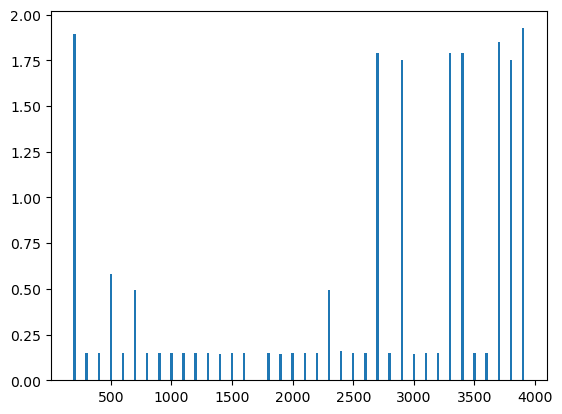

In [7]:
plt.bar(Costs, average_cost, width=20);

In [ ]:
plt.figure(figsize=(10,50));
for i in range(len(logging)):
    plt.subplot(7,1,i+1)
    indicators = np.transpose(np.array(logging[i].indicators))
    #plt.plot(indicators[9], label = 'Installed');
    plt.plot(indicators[10], label = 'Under Construction')
    plt.plot(logging[i].capacity, label = 'capacity')
    plt.legend();

In [ ]:
plt.figure(figsize=(10,50));
for i in range(len(logging)):
    plt.subplot(7, 1,i+1)
    plt.plot(logging[i].reduction_magn, label = f"{i}");
    plt.xlabel('Time (Months)');
    plt.ylabel('Demand Reduction (Af/Mo)');

In [ ]:
for i in range(len(logging)):
    plt.plot(logging[i].def_penalty, label = f"{i}");
plt.legend();

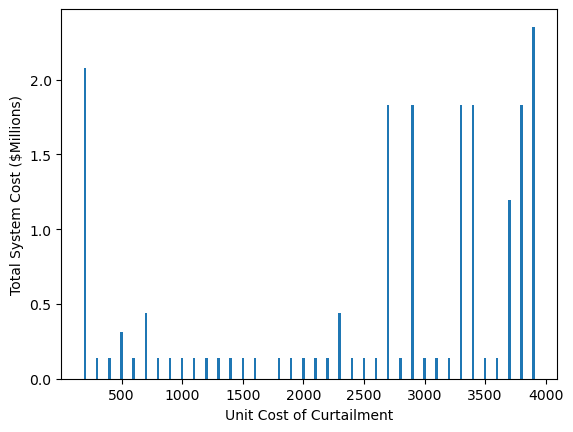

In [89]:
System_Costs = [val.Cost for val in logging]
#print((System_Costs))
plt.bar(Costs,System_Costs, width=20)
plt.xlabel("Unit Cost of Curtailment");
plt.ylabel("Total System Cost ($Millions)");

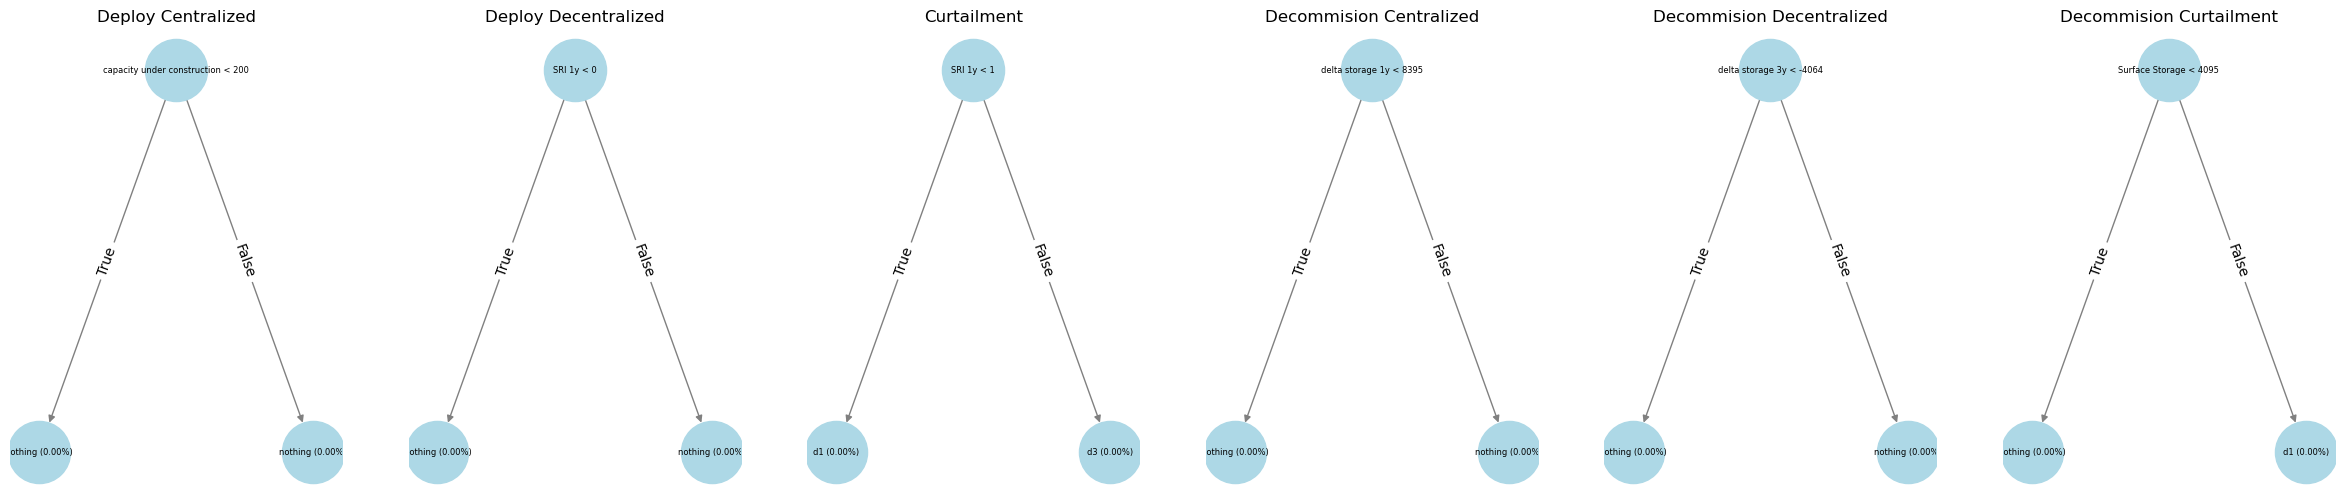

In [60]:
plot_trees(objs[1].best_solution);

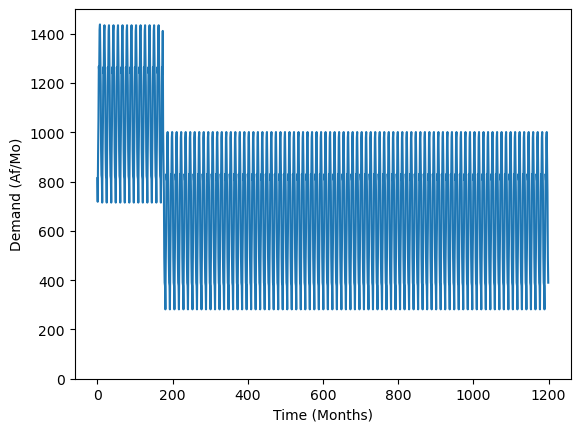

In [22]:
plt.plot(logging[1].curtailed_demand, label = f"{1}");
plt.xlabel('Time (Months)');
plt.ylabel('Demand (Af/Mo)');
plt.ylim(0,1500);

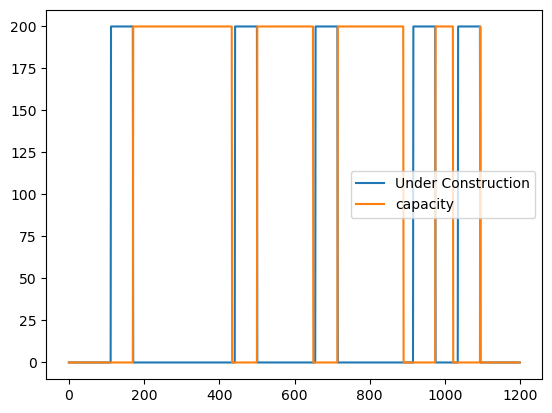

In [63]:
i = 0
indicators = np.transpose(np.array(logging[i].indicators))
plt.plot(indicators[10], label = 'Under Construction')
plt.plot(logging[i].capacity, label = 'capacity')
plt.legend();

Plotting the results from the optimization parameter sweep

In [ ]:
#file structure /home/gkittles/SB_DRIPP_Results/2_24_25_Optimization_Params/testing_[nfe]_[mu]_[mut_prob]_[cx_prob].dat
nfe = [100000, 200000, 300000, 400000]
mu = [5,10,15]
mu_prob = [0.1, 0.3, 0.5, 0.7, 0.9]
cx_prob = [0.1, 0.3, 0.5, 0.7, 0.9]

nfe_val = []
mu_val = []
mu_prob_val = []
cx_prob_val = []
obj_list = []
log_list = []
cost_list = []

#objects = []
#logging = []
for i in range(4):

    #obj_int1 = []
    #log_int1 = []
    for j in range(3):

        #obj_int2 = []
        #log_int2 = []
        for k in range(5):

            #obj_int3 = []
            #log_int3 = []
            for l in range(5):
                if os.path.exists(f"/home/gkittles/SB_DRIPP_Results/2_24_25_Optimization_Params/test_results{str(nfe[i])}_{str(mu[j])}_{str(mu_prob[k])}_{str(cx_prob[l])}.dat"):
                    open_file = open(f"/home/gkittles/SB_DRIPP_Results/2_24_25_Optimization_Params/test_results{str(nfe[i])}_{str(mu[j])}_{str(mu_prob[k])}_{str(cx_prob[l])}.dat", "rb")
                    obj = pickle.load(open_file)
                    log = model_sim_OG.simulate(obj.best_solution, 49)
                    nfe_val.append(nfe[i])
                    mu_val.append(mu[j])
                    mu_prob_val.append(mu_prob[k])
                    cx_prob_val.append(cx_prob[l])
                    obj_list.append(obj)
                    log_list.append(log)
                    cost_list.append(log.Cost)
                #obj_int3.append(obj)
                #log_int3.append(log)
            #obj_int2.append(obj_int3)
            #log_int2.append(log_int3)
        #obj_int1.append(obj_int2)
        #log_int1.append(log_int2)
    #objects.append(obj_int1)
    #logging.append(log_int1)

data = {'nfe': nfe_val, 'mu': mu_val, 'mut_prob': mu_prob_val, 'cx_prob': cx_prob_val, 'Object': obj_list, 'Log': log_list, 'Cost': cost_list}
df = pd.DataFrame(data)

In [ ]:
cost_100000 = []
for log in df.loc[df['nfe'] == 100000]['Log'].values:
    cost_100000.append(log.Cost)

cost_200000 = []
for log in df.loc[df['nfe'] == 200000]['Log'].values:
    cost_200000.append(log.Cost)

cost_300000 = []
for log in df.loc[df['nfe'] == 300000]['Log'].values:
    cost_300000.append(log.Cost)

cost_400000 = []
for log in df.loc[df['nfe'] == 400000]['Log'].values:
    cost_400000.append(log.Cost)

In [ ]:
plt.scatter(100000*np.ones(len(cost_100000)), cost_100000)
plt.scatter(200000*np.ones(len(cost_200000)), cost_200000)
plt.scatter(300000*np.ones(len(cost_300000)), cost_300000)
plt.scatter(400000*np.ones(len(cost_400000)), cost_400000)
plt.xlabel("Number of Function Evaluations")
plt.ylabel("Cost ($Millions)");

In [ ]:
fig = px.parallel_coordinates(df, color="Cost", labels={"nfe": "NFE", "mu": "Mu", "mut_prob": "Mutation Prob"}, dimensions=['nfe','mu', 'mut_prob'])
fig.show()

In [ ]:
plt.figure(figsize=(30,10))
i = 1
for val in mu:
    for val2 in mu_prob:
        plt.subplot(3,5,i)
        df_ = df.loc[df['mu'] == val]
        df_2 = df_.loc[df_['mut_prob'] == val2]
        array = []
        for val3 in nfe:
            mini = []
            for log in df_2.loc[df_2['nfe'] == val3]['Log'].values:
                mini.append(log.Cost)
            array.append(mini)
        plt.boxplot(array, tick_labels = ['100,000', '200,000', '300,000', '400,000']);
        plt.title(f"Mu:{val}, Mutation Prob:{val2}");
        plt.ylim(0,1);
        i = i + 1

In [ ]:
plt.figure(figsize=(30,10))
i = 1
for val in mu:
    for val2 in nfe:
        plt.subplot(3,4,i)
        df_ = df.loc[df['mu'] == val]
        df_2 = df_.loc[df_['nfe'] == val2]
        array = []
        for val3 in mu_prob:
            mini = []
            for log in df_2.loc[df_2['mut_prob'] == val3]['Log'].values:
                mini.append(log.Cost)
            array.append(mini)
        plt.boxplot(array, tick_labels = ['0.1','0.3','0.5','0.7','0.9']);
        plt.title(f"Mu:{val}, NFE:{val2}");
        plt.ylim(0,1);
        i = i + 1

In [ ]:
plt.figure(figsize=(30,10))
i = 1
for val in nfe:
    for val2 in mu_prob:
        plt.subplot(4,5,i)
        df_ = df.loc[df['nfe'] == val]
        df_2 = df_.loc[df_['mut_prob'] == val2]
        array = []
        for val3 in mu:
            mini = []
            for log in df_2.loc[df_2['mu'] == val3]['Log'].values:
                mini.append(log.Cost)
            array.append(mini)
        plt.boxplot(array, tick_labels = ['5','10','15']);
        plt.title(f"NFE:{val}, Mutation Prob:{val2}");
        plt.ylim(0,1);
        i = i + 1